# VK Fest: ESG-программа «Хороший след» — анализ данных и сценарная модель

**Автор:** Анастасия Щугарева · **Стек:** Python, pandas, NumPy, matplotlib

Ноутбук сопровождает проект ESG-программы для VK Fest. Здесь собрана аналитическая часть: что показывают открытые отчёты VK за 2022–2024 годы, какие ориентиры дают зарубежные фестивали и сколько может дать программа в сезоне 2027 года, если перевести её инициативы в цифры.

**Что внутри**

1. Исторические данные ESG-инициатив VK Fest 2022–2024
2. Бенчмарки: возврат многоразовых стаканов, доля переработки, структура выбросов
3. Сценарная модель залоговых стаканов для сезона 2027 (Монте-Карло)
4. Модель отходов: сколько можно отправить на переработку
5. Бюджет программы и чувствительность к партнёрскому софинансированию
6. Дерево KPI и выводы

**Источники:** блог ESG VK (материалы о VK Fest 2022, 2023, 2024), итоги VK Fest 2025 (vk.ru/press), Экологическая политика VK (2024), Roskilde Festival FAQ, Packaging Europe о Tomorrowland 2025, Belga News Agency, отчёт Powerful Thinking «The Show Must Go On».

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option('display.float_format', lambda x: f'{x:,.1f}'.replace(',', ' '))
plt.rcParams.update({
    'figure.figsize': (10, 5), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'axes.titleweight': 'bold',
    'axes.titlesize': 13, 'font.size': 11,
})
GREEN, CORAL, BLUE, INK, GREY = '#15935a', '#ee5a36', '#1a5cff', '#14161c', '#9aa0ae'
rng = np.random.default_rng(42)

## 1. Что VK Fest уже сделал: данные 2022–2024

Цифры взяты из публичных материалов VK. Прочерк (`NaN`) означает, что показатель в отчёте за этот год не публиковался, а не то, что он равен нулю. Это важное ограничение: ряд неполный, и сравнивать годы напрямую можно не везде.

In [2]:
hist = pd.DataFrame({
    'год': [2022, 2023, 2024],
    'вторсырьё, т': [0.58, np.nan, 30.8],          # 2022: 230 кг вторсырья + 350 кг макулатуры
    'смешанные отходы, т': [35.0, np.nan, np.nan],
    'материалы на повторное использование, т': [5.0, np.nan, 27.5],
    'многоразовые стаканы, шт': [np.nan, 3174 / 3, 3174],  # в 2024 закуплено втрое больше, чем в 2023
    'благотворительность, млн ₽': [np.nan, 2.5, 2.0],
    'гости с инвалидностью': [np.nan, 900, 1000],
    'зрители трансляции с РЖЯ, млн': [np.nan, 2.0, 4.5],
    'городов с раздельным сбором': [2, 2, 2],
}).set_index('год')
hist

,"вторсырьё, т","смешанные отходы, т","материалы на повторное использование, т","многоразовые стаканы, шт","благотворительность, млн ₽",гости с инвалидностью,"зрители трансляции с РЖЯ, млн",городов с раздельным сбором
год,,,,,,,,
2022,0.6,35.0,5.0,NaN,NaN,NaN,NaN,2
2023,NaN,NaN,NaN,1 058.0,2.5,900.0,2.0,2
2024,30.8,NaN,27.5,3 174.0,2.0,1 000.0,4.5,2


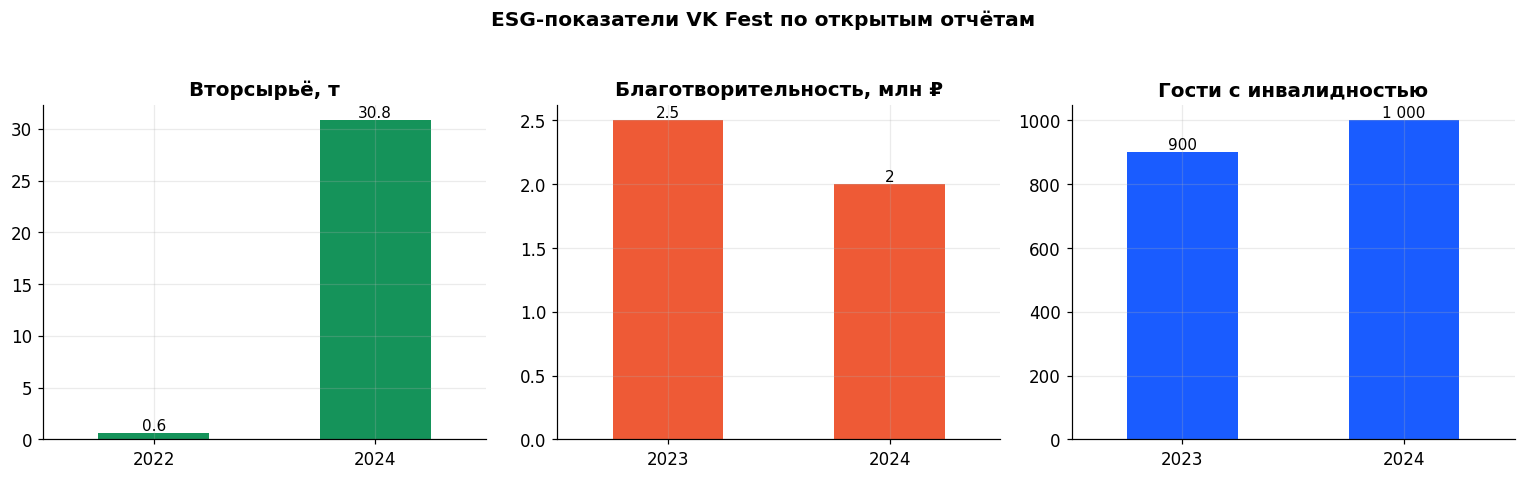

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

hist['вторсырьё, т'].dropna().plot.bar(ax=axes[0], color=GREEN, rot=0)
axes[0].set_title('Вторсырьё, т')
axes[0].set_xlabel('')

hist['благотворительность, млн ₽'].dropna().plot.bar(ax=axes[1], color=CORAL, rot=0)
axes[1].set_title('Благотворительность, млн ₽')
axes[1].set_xlabel('')

hist['гости с инвалидностью'].dropna().plot.bar(ax=axes[2], color=BLUE, rot=0)
axes[2].set_title('Гости с инвалидностью')
axes[2].set_xlabel('')

for ax in axes:
    for p in ax.patches:
        ax.annotate(f'{p.get_height():,.1f}'.replace(',', ' ').replace('.0', ''),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)
plt.suptitle('ESG-показатели VK Fest по открытым отчётам', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

**Что видно.** Вторсырья стало в 50 с лишним раз больше, но это эффект масштаба и методики, а не только качества сортировки. Долю переработки посчитать нельзя: после 2022 года общую массу отходов не публикуют. Благотворительные сборы снизились с 2,5 до 2 млн ₽. Доступность — единственный блок со стабильным ростом.

Отсюда первая рекомендация для программы: **взвешивать весь поток отходов**, иначе главную экологическую метрику не посчитать.

## 2. Бенчмарки

Ориентиры из открытых источников, на которые опирается программа.

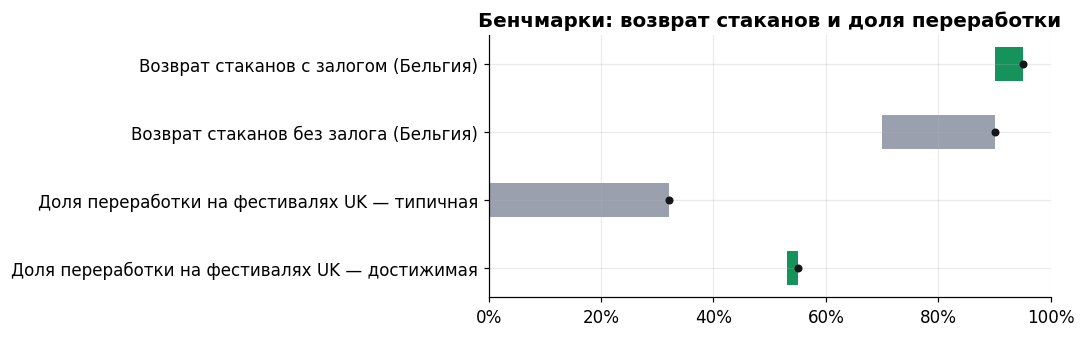

In [4]:
bench = pd.DataFrame([
    ['Возврат стаканов с залогом (Бельгия)', 0.90, 0.95],
    ['Возврат стаканов без залога (Бельгия)', 0.70, 0.90],
    ['Доля переработки на фестивалях UK — типичная', 0.00, 0.32],
    ['Доля переработки на фестивалях UK — достижимая', 0.53, 0.55],
], columns=['показатель', 'min', 'max'])

fig, ax = plt.subplots(figsize=(10, 3.2))
y = np.arange(len(bench))
ax.barh(y, bench['max'] - bench['min'], left=bench['min'], color=[GREEN, GREY, GREY, GREEN], height=0.5)
ax.scatter(bench['max'], y, color=INK, zorder=3, s=18)
ax.set_yticks(y, bench['показатель'])
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.set_title('Бенчмарки: возврат стаканов и доля переработки')
plt.tight_layout(); plt.show()

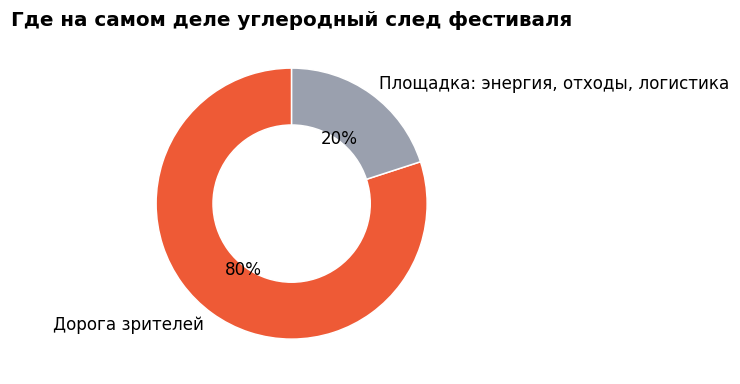

In [5]:
# Структура выбросов фестиваля по отчёту The Show Must Go On (UK):
# до 80% — дорога зрителей, около 20% — сама площадка
emissions = pd.Series({'Дорога зрителей': 80, 'Площадка: энергия, отходы, логистика': 20})
fig, ax = plt.subplots(figsize=(6, 4))
ax.pie(emissions, labels=emissions.index, autopct='%1.0f%%', colors=[CORAL, GREY],
       startangle=90, wedgeprops=dict(width=0.42, edgecolor='white'))
ax.set_title('Где на самом деле углеродный след фестиваля')
plt.show()

**Вывод.** Залог — самый проверенный рычаг: он поднимает возврат стаканов до 90–95%. А главный углеродный след оставляет не сцена, а дорога гостей, поэтому в программе есть отдельный транспортный блок.

## 3. Сценарная модель: залоговые стаканы в сезоне 2027

Моделируем пять городов. Посещаемость взята из итогов VK Fest 2025 (205 тыс. гостей, из них 85 тыс. в Москве). Для остальных городов распределение оценочное.

Допущения модели:

- гость покупает в среднем 2–4 напитка за день;
- с залогом возвращается 85–95% стаканов (бенчмарк Бельгии), часть гостей забирает стакан как сувенир;
- в 2027 году стаканы есть в Москве и Петербурге и пилотно в одном регионе, в 2028-м — во всех городах;
- один одноразовый стакан весит около 10 г.

Неопределённость закладываем через Монте-Карло: 10 000 прогонов.

In [6]:
cities = pd.DataFrame({
    'город': ['Москва', 'Санкт-Петербург', 'Казань', 'Челябинск', 'Сириус'],
    'гости': [85_000, 60_000, 25_000, 20_000, 15_000],
    'стаканы_2027': [1, 1, 1, 0, 0],   # пилот в одном регионе
})
assert cities['гости'].sum() == 205_000
cities

,город,гости,стаканы_2027
0,Москва,85000,1
1,Санкт-Петербург,60000,1
2,Казань,25000,1
3,Челябинск,20000,0
4,Сириус,15000,0


In [7]:
N = 10_000
CUP_WEIGHT_KG = 0.010

def simulate(cities, coverage_col):
    guests = (cities['гости'] * cities[coverage_col]).sum()
    drinks_per_guest = rng.triangular(2, 3, 4, N)
    return_rate = rng.uniform(0.85, 0.95, N)
    drinks = guests * drinks_per_guest
    # без залоговой системы каждый напиток = один одноразовый стакан
    single_use_avoided = drinks
    cups_kept = guests * (1 - return_rate)          # один стакан на гостя, который забирают домой
    waste_avoided_t = single_use_avoided * CUP_WEIGHT_KG / 1000
    return pd.DataFrame({
        'напитков': drinks,
        'возврат': return_rate,
        'одноразовых стаканов не выброшено': single_use_avoided,
        'стаканов унесли домой': cups_kept,
        'отходов предотвращено, т': waste_avoided_t,
    })

cities['стаканы_2028'] = 1
sim27 = simulate(cities, 'стаканы_2027')
sim28 = simulate(cities, 'стаканы_2028')

summary = pd.DataFrame({
    '2027 · P10': sim27.quantile(0.1), '2027 · медиана': sim27.median(), '2027 · P90': sim27.quantile(0.9),
    '2028 · медиана': sim28.median(),
}).drop(['возврат', 'напитков'])
summary

,2027 · P10,2027 · медиана,2027 · P90,2028 · медиана
одноразовых стаканов не выброшено,416 631.1,509 711.0,602 975.1,615 433.8
стаканов унесли домой,10 192.4,16 869.9,23 755.9,20 384.2
"отходов предотвращено, т",4.2,5.1,6.0,6.2


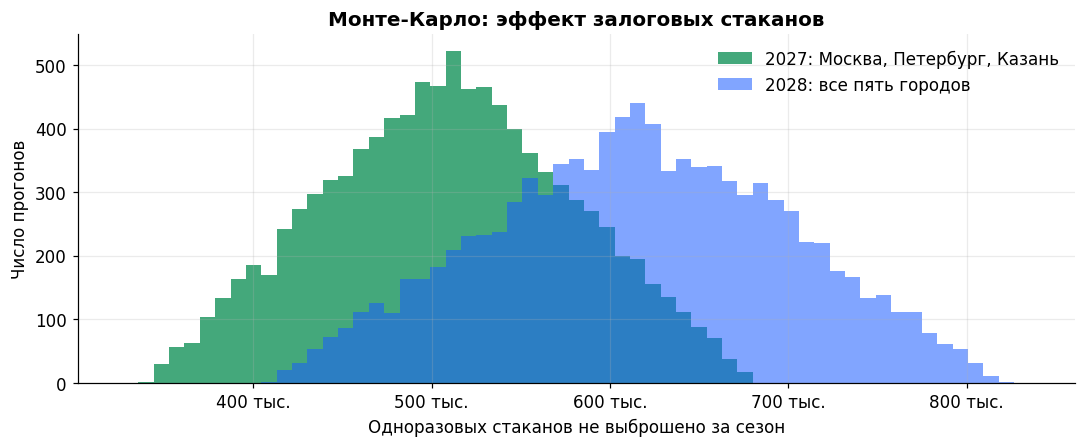

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.2))
bins = np.linspace(sim27['одноразовых стаканов не выброшено'].min() * 0.95, sim28['одноразовых стаканов не выброшено'].max() * 1.02, 60)
ax.hist(sim27['одноразовых стаканов не выброшено'], bins=bins, color=GREEN, alpha=0.8, label='2027: Москва, Петербург, Казань')
ax.hist(sim28['одноразовых стаканов не выброшено'], bins=bins, color=BLUE, alpha=0.55, label='2028: все пять городов')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f} тыс.'))
ax.set_xlabel('Одноразовых стаканов не выброшено за сезон')
ax.set_ylabel('Число прогонов')
ax.set_title('Монте-Карло: эффект залоговых стаканов')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

### Сколько стаканов закупать

Закупка определяется пиковым днём и оборачиваемостью: стакан проходит мойку и возвращается на бар несколько раз за день. Считаем, сколько стаканов нужно, чтобы покрыть самый загруженный город (Москву) с запасом на потери.

In [9]:
peak_guests = 85_000
drinks_peak = peak_guests * 3                    # медианный сценарий
turns_per_day = np.array([4, 5, 6, 7, 8])        # сколько раз стакан проходит цикл «бар — мойка — бар»
loss_buffer = 1.15                               # 15% унесут домой или повредят

need = pd.DataFrame({
    'оборотов в день': turns_per_day,
    'нужно стаканов': np.ceil(drinks_peak / turns_per_day * loss_buffer).astype(int),
})
need

,оборотов в день,нужно стаканов
0,4,73313
1,5,58650
2,6,48875
3,7,41893
4,8,36657


При 6–8 оборотах в день пиковой Москве нужно 37–49 тыс. стаканов. Закладываем в бюджет **40 000 штук**: комплект переезжает из города в город, и если мойка работает быстро, этого хватает.

## 4. Модель отходов: доля переработки

Базы для расчёта нет: общую массу отходов VK после 2022 года не раскрывал. Поэтому берём удельный показатель из 2022 года — 35 т смешанных отходов на Москву и Петербург — и строим сценарии для сезона 2027.

- **База:** вторсырья столько же, сколько в 2024 году, по гостю;
- **Программа:** раздельный сбор в 5 городах, эко-патруль, залоговые стаканы;
- **Цель 2029:** 40% отходов уходит на переработку.

In [10]:
KG_PER_GUEST = 0.80   # кг отходов на гостя; калибровка: при 20% переработки выходит ~31 т вторсырья, как в отчёте за 2024 год
total_guests = cities['гости'].sum()
total_waste_t = total_guests * KG_PER_GUEST / 1000

scenarios = pd.DataFrame({
    'сценарий': ['База (как в 2024)', 'Программа 2027', 'Программа 2028', 'Цель 2029'],
    'доля переработки': [0.20, 0.30, 0.35, 0.40],
    'снижение общего объёма': [0.00, 0.08, 0.12, 0.15],   # за счёт стаканов, воды, отказа от полиграфии
})
scenarios['всего отходов, т'] = total_waste_t * (1 - scenarios['снижение общего объёма'])
scenarios['на переработку, т'] = scenarios['всего отходов, т'] * scenarios['доля переработки']
scenarios['на полигон, т'] = scenarios['всего отходов, т'] - scenarios['на переработку, т']
scenarios.set_index('сценарий').style.format({'доля переработки': '{:.0%}', 'снижение общего объёма': '{:.0%}', 'всего отходов, т': '{:.1f}', 'на переработку, т': '{:.1f}', 'на полигон, т': '{:.1f}'})

,доля переработки,снижение общего объёма,"всего отходов, т","на переработку, т","на полигон, т"
сценарий,,,,,
База (как в 2024),20%,0%,164.0,32.8,131.2
Программа 2027,30%,8%,150.9,45.3,105.6
Программа 2028,35%,12%,144.3,50.5,93.8
Цель 2029,40%,15%,139.4,55.8,83.6


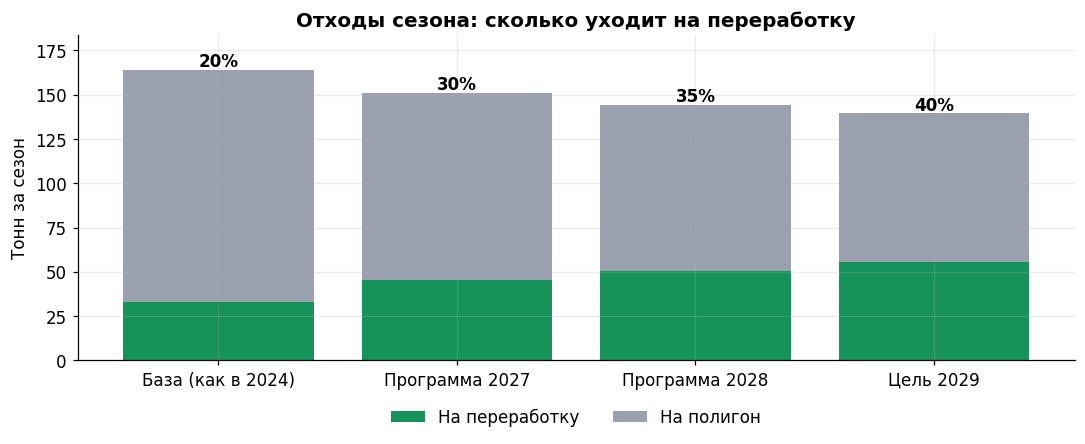

In [11]:
s = scenarios.set_index('сценарий')
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(s.index, s['на переработку, т'], color=GREEN, label='На переработку')
ax.bar(s.index, s['на полигон, т'], bottom=s['на переработку, т'], color=GREY, label='На полигон')
for i, (r, t) in enumerate(zip(s['доля переработки'], s['всего отходов, т'])):
    ax.text(i, t + 2, f'{r:.0%}', ha='center', fontweight='bold')
ax.set_ylabel('Тонн за сезон')
ax.set_title('Отходы сезона: сколько уходит на переработку')
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
ax.set_ylim(0, s['всего отходов, т'].max() * 1.12)
plt.tight_layout(); plt.show()

## 5. Бюджет программы

Бюджет сезона 2027 года по статьям, млн ₽. Управление программой — 5%, резерв — 10%.

In [12]:
budget = pd.DataFrame([
    ('Экология', 'Залоговые стаканы: закупка, мойка, логистика', 7.2),
    ('Экология', 'Раздельный сбор 2.0 в 5 городах', 4.2),
    ('Экология', 'Станции питьевой воды', 1.5),
    ('Экология', 'Лаборатория переработки', 1.4),
    ('Экология', 'Эко-патруль, 300 волонтёров', 1.3),
    ('Экология', 'Апсайкл-коллекция из баннеров', 1.2),
    ('Экология', 'Велопарковки, энерго-зона', 1.0),
    ('Экология', 'Замер углеродного следа, аудит', 0.9),
    ('Социальное', 'Доступная среда+', 3.8),
    ('Социальное', 'Ярмарка добрых дел', 1.8),
    ('Социальное', 'Зона здоровья', 0.7),
    ('Социальное', 'Интеграция с VK Добро', 0.6),
    ('Вовлечение', 'Квест «Хороший след»', 2.4),
    ('Вовлечение', 'Зелёная сцена', 1.3),
    ('Коммуникации', 'Контент и амбассадоры', 2.8),
    ('Коммуникации', 'Исследования, brand lift', 0.8),
    ('Коммуникации', 'Публичный отчёт', 0.4),
], columns=['блок', 'статья', 'млн ₽'])

program = budget['млн ₽'].sum()
pm = round(program * 0.05, 1)
reserve = round((program + pm) * 0.10, 1)
total = program + pm + reserve
print(f'Программа: {program:.1f} млн ₽ · управление: {pm} · резерв: {reserve} · ИТОГО: {total:.1f} млн ₽')
budget.groupby('блок')['млн ₽'].sum().sort_values(ascending=False).to_frame()

Программа: 33.3 млн ₽ · управление: 1.7 · резерв: 3.5 · ИТОГО: 38.5 млн ₽


,млн ₽
блок,
Экология,18.7
Социальное,6.9
Коммуникации,4.0
Вовлечение,3.7


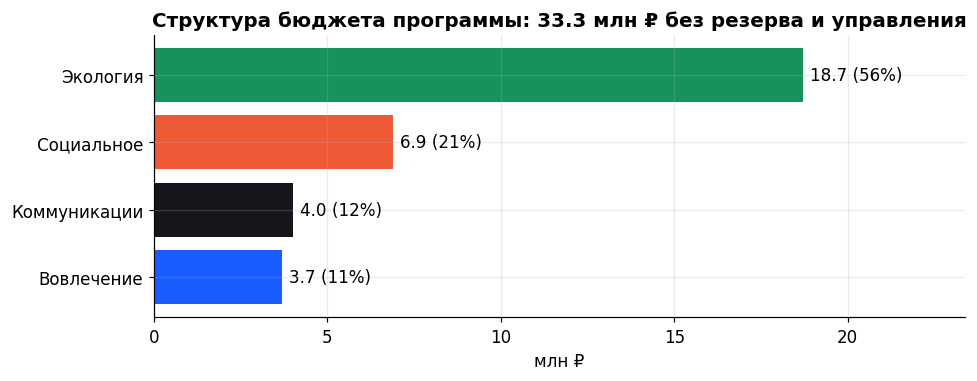

In [13]:
by_block = budget.groupby('блок')['млн ₽'].sum().sort_values()
colors = {'Экология': GREEN, 'Социальное': CORAL, 'Вовлечение': BLUE, 'Коммуникации': INK}
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(by_block.index, by_block.values, color=[colors[b] for b in by_block.index])
for i, v in enumerate(by_block.values):
    ax.text(v + 0.2, i, f'{v:.1f} ({v/program:.0%})', va='center')
ax.set_xlabel('млн ₽')
ax.set_title(f'Структура бюджета программы: {program:.1f} млн ₽ без резерва и управления')
ax.set_xlim(0, by_block.max() * 1.25)
plt.tight_layout(); plt.show()

### Чувствительность: сколько остаётся на VK

Кроме бюджета VK программу финансируют генеральные ESG-партнёры, натуральный вклад операторов и НКО, а также залоги за стаканы, которые гости уносят домой. Посмотрим, как чистая нагрузка на VK зависит от числа партнёров и стоимости пакета.

In [14]:
in_kind = 2.0
# консервативно: считаем, что залог покрывает стоимость 15% закупленных стаканов (150 ₽ за штуку);
# модель выше показывает, что гости могут унести и больше — тогда нагрузка на VK будет ниже
cups_kept_income = 40_000 * 0.15 * 150 / 1e6

partners = np.arange(0, 6)
package = np.array([2.0, 3.0, 4.0])
grid = pd.DataFrame(
    {f'пакет {p:.0f} млн': [total - n * p - in_kind - cups_kept_income for n in partners] for p in package},
    index=pd.Index(partners, name='партнёров'),
)
grid.style.format('{:.1f}').background_gradient(cmap='RdYlGn_r', axis=None)

,пакет 2 млн,пакет 3 млн,пакет 4 млн
партнёров,,,
0,35.6,35.6,35.6
1,33.6,32.6,31.6
2,31.6,29.6,27.6
3,29.6,26.6,23.6
4,27.6,23.6,19.6
5,25.6,20.6,15.6


Базовый сценарий — три партнёра по 3 млн ₽: на VK остаётся около 26,6 млн ₽. Каждый дополнительный партнёр такого уровня снижает нагрузку примерно на 8%.

## 6. KPI сезона 2027

Базовые значения — из отчётов VK, цели — из бенчмарков и модели выше.

In [15]:
kpi = pd.DataFrame([
    ('Экология', 'Доля отходов на переработку', 'нет данных', 'замер базы; 2028 ≥ 30%, 2029 ≥ 40%'),
    ('Экология', 'Масса вторсырья', '30,8 т (2024)', '≥ 45 т'),
    ('Экология', 'Возврат залоговых стаканов', '—', '≥ 85%'),
    ('Экология', 'Материалы на повторное использование', '27,5 т (2024)', '≥ 30 т'),
    ('Социальное', 'Собрано на благотворительность', '2 млн ₽ (2024)', '≥ 5 млн ₽'),
    ('Социальное', 'Гости с инвалидностью', '1 000 (2024)', '≥ 1 500'),
    ('Социальное', 'Обследования и вступления в регистр доноров', '~1 400 (2023)', '≥ 1 500'),
    ('Вовлечение', 'Доля гостей в квесте', '—', '≥ 25%'),
    ('Вовлечение', 'Знают хотя бы одну ESG-инициативу', 'замер 2027', '≥ 60%'),
    ('Имидж', '«VK — ответственная компания»', 'замер до', '+10 п.п. к контрольной группе'),
], columns=['блок', 'метрика', 'база', 'цель 2027'])
kpi

,блок,метрика,база,цель 2027
0,Экология,Доля отходов на переработку,нет данных,"замер базы; 2028 ≥ 30%, 2029 ≥ 40%"
1,Экология,Масса вторсырья,"30,8 т (2024)",≥ 45 т
2,Экология,Возврат залоговых стаканов,—,≥ 85%
3,Экология,Материалы на повторное использование,"27,5 т (2024)",≥ 30 т
4,Социальное,Собрано на благотворительность,2 млн ₽ (2024),≥ 5 млн ₽
5,Социальное,Гости с инвалидностью,1 000 (2024),≥ 1 500
6,Социальное,Обследования и вступления в регистр доноров,~1 400 (2023),≥ 1 500
7,Вовлечение,Доля гостей в квесте,—,≥ 25%
8,Вовлечение,Знают хотя бы одну ESG-инициативу,замер 2027,≥ 60%
9,Имидж,«VK — ответственная компания»,замер до,+10 п.п. к контрольной группе


## Выводы

1. **Данные неполные.** Открытые отчёты не позволяют посчитать долю переработки. Первое, что нужно программе, — единая методика учёта и взвешивание всего потока отходов.
2. **Залоговые стаканы дают самый заметный эффект.** По медианному сценарию уже в 2027 году гости не выбросят около полумиллиона одноразовых стаканов, а в 2028-м — больше 600 тысяч. Для этого нужно около 40 тыс. стаканов в обороте.
3. **Доля переработки 40% к 2029 году реалистична**, если раздельный сбор работает во всех городах, а общий объём отходов снижается за счёт стаканов, станций воды и отказа от полиграфии.
4. **Бюджет — около 38,5 млн ₽.** С тремя ESG-партнёрами нагрузка на VK снижается до ~26,6 млн ₽.
5. **Главный резерв — транспорт гостей.** На него приходится до 80% выбросов, а в открытых данных VK Fest он пока вообще не измеряется.